<a href="https://colab.research.google.com/github/mark4335/cybersecurity_DataAnalytics-/blob/main/Cleaning_Real_World_Firewall_Logs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Name: Mark Waako
#StudentID: 112107263
import pandas as pd

df = pd.read_csv('/content/raw_firewall_logs.csv')

In [ ]:
#Report shape
display(df.columns)

df.shape
display("Rows:", df.shape[0])
display("Columns:", df.shape[1])

display(f"duplicates {df.duplicated().sum()}")

Index(['event_time', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol',
       'action', 'bytes_in', 'bytes_out', 'country', 'device'],
      dtype='object')

'Rows:'

1010

'Columns:'

11

'duplicates 10'

In [ ]:
#Name: Mark Waako
#StudentID: 112107263

# 1. Identify standard NaNs across the entire DataFrame
nan_mask = df.isna()

string_cols = df.select_dtypes(include=["object", "string"]).columns
empty_str_mask = df[string_cols].astype(str).stack().str.strip().eq("").unstack()

missing_sorted = (
    nan_mask.add(empty_str_mask, fill_value=False)
    .sum()
    .sort_values(ascending=False)
)

display(missing_sorted)

,0
src_port,26
dst_port,25
country,16
event_time,12
bytes_in,6
bytes_out,6
src_ip,0
dst_ip,0
protocol,0
action,0


In [ ]:
#convert all text in the DataFrame to uppercase
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.upper()
#Remove all commas
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.replace(',', '')
display(df.shape)

(1010, 11)

In [ ]:
#Name: Mark Waako
#StudentID: 112107263

df['event_time'] = pd.to_datetime(
    df['event_time'],
    errors='coerce',
    format='mixed'
).dt.strftime('%Y-%m-%d %H:%M:%S')

In [ ]:
#Name: Mark Waako
#StudentID: 112107263
pattern = r"^((25[0-5]|2[0-4][0-9]|[01]?\d?\d?)\.){3}(25[0-5]|2[0-4][0-9]|[01]?\d?\d?)$"

# Strip whitespace
df["src_ip"] = df["src_ip"].astype(str).str.strip()
df["dst_ip"] = df["dst_ip"].astype(str).str.strip()

df["src_ip"] = df["src_ip"].replace("-", pd.NA)
df["dst_ip"] = df["dst_ip"].replace("-", pd.NA)

# Valid IPv4
valid_src = df["src_ip"].str.match(pattern, na=False)
valid_dst = df["dst_ip"].str.match(pattern, na=False)
# Replace invalid IPs with NaN (keep rows)
df.loc[~valid_src, "src_ip"] = pd.NA
df.loc[~valid_dst, "dst_ip"] = pd.NA

display(df.shape)


(1010, 11)

In [ ]:
#Name: Mark Waako
#StudentID: 112107263

df["src_port"] = df["src_port"].astype(str).str.replace(",", "", regex=False)
df["dst_port"] = df["dst_port"].astype(str).str.replace(",", "", regex=False)

# Coerce to numeric (invalid → NaN)
df["src_port"] = pd.to_numeric(df["src_port"], errors="coerce")
df["dst_port"] = pd.to_numeric(df["dst_port"], errors="coerce")

# Set out-of-range values to NaN
df.loc[(df["src_port"] < 0) | (df["src_port"] > 65535), "src_port"] = pd.NA
df.loc[(df["dst_port"] < 0) | (df["dst_port"] > 65535), "dst_port"] = pd.NA

display(df.shape)

(1010, 11)

In [ ]:
#Name: Mark Waako
#StudentID: 112107263

df["protocol"] = df["protocol"].astype(str).str.strip().str.upper()

valid_protocols = {"TCP", "UDP", "ICMP", "GRE", "ESP"}


df.loc[~df["protocol"].isin(valid_protocols), "protocol"] = pd.NA
display(df.shape)

(1010, 11)

In [ ]:

#Name: Mark Waako
#StudentID: 112107263
# Trim whitespace and normalize case
df["action"] = df["action"].astype(str).str.strip().str.upper()

# Standard mapping
action_mapping = {
    "ALLOWED": "ALLOW",
    "ALLOW": "ALLOW",
    "DENIED": "DENY",
    "DENY": "DENY"
}

# Apply mapping
df["action"] = df["action"].replace(action_mapping)

# Keep only valid categories, others → NaN
valid_actions = {"ALLOW", "DENY"}
df.loc[~df["action"].isin(valid_actions), "action"] = pd.NA
display(df.shape)

(1010, 11)

In [ ]:
#Name: Mark Waako
#StudentID: 112107263
df["bytes_out"] = df["bytes_out"].astype(str).str.strip().str.lower()
df["bytes_in"] = df["bytes_in"].astype(str).str.strip().str.lower()

df["bytes_in"] = df["bytes_in"].str.replace(",", "", regex=False)
df["bytes_out"] = df["bytes_out"].str.replace(",", "", regex=False)

k = df["bytes_in"].str.contains("k", na=False)
k = df["bytes_out"].str.contains("k", na=False)
# Extract numeric portion
numeric_part = df["bytes_out"].str.extract(r"([\d\.]+)")[0]
numeric_part = pd.to_numeric(numeric_part, errors="coerce")

df["bytes_out"] = numeric_part.where(~k, numeric_part * 1000)
df["bytes_in"] = numeric_part.where(~k, numeric_part * 1000)

df.loc[df["bytes_in"] < 0, "bytes_in"] = 0
df.loc[df["bytes_out"] < 0, "bytes_out"] = 0
display(df.shape)

(1010, 11)

In [ ]:
#Name:Mark Waako
#StudentID:112107263
df["country"] = df["country"].astype(str).str.strip().str.upper()

df["country"] = df["country"].replace("", pd.NA)

df['country'] = df['country'].replace('UNITED STATES', 'US')
df['country'] = df['country'].replace('CANADA', 'CA')

In [ ]:
#Name:Mark Waako
#StudentID:112107263
df["device"] = df["device"].astype(str).str.strip()

In [ ]:
#Name:Mark Waako
#StudentID:112107263

dup_count = df.duplicated().sum()
df = df.drop_duplicates()

display(df.shape)


(1000, 11)

In [ ]:
display(df.sample(10))

,event_time,src_ip,dst_ip,src_port,dst_port,protocol,action,bytes_in,bytes_out,country,device
493,2025-09-10 00:38:00,47.167.178.170,215.240.71.220,8660.0,12979.0,TCP,ALLOW,16037.0,16037.0,AU,BR-FW-1
562,2025-01-01 13:36:00,80.243.82.42,143.1.23.206,10223.0,29672.0,GRE,ALLOW,48436.0,48436.0,JP,BR-FW-1
324,NaN,73.222.14.4,172.30.77.147,13696.0,21751.0,GRE,DENY,37220.0,37220.0,BR,CLOUDGW-2
42,2025-04-06 02:38:00,247.28.160.235,57.177.73.98,18895.0,48217.0,TCP,DENY,27955.0,27955.0,US,FW-02
705,2025-01-16 13:20:00,<NA>,192.168.50.76,26149.0,27617.0,TCP,DENY,48024.0,48024.0,RU,CLOUDGW-1
672,2025-12-16 03:26:00,168.2.246.117,<NA>,48738.0,37869.0,UDP,ALLOW,5312.0,5312.0,ES,BR-FW-1
582,2025-06-11 08:45:00,2.103.83.226,214.68.175.40,21548.0,51158.0,ICMP,ALLOW,9290.0,9290.0,NL,CLOUDGW-2
652,2025-02-08 09:59:00,83.46.5.16,210.223.205.175,9638.0,59262.0,ICMP,ALLOW,25106.0,25106.0,JP,DC-FW
512,2025-01-02 07:10:00,122.102.219.106,8.37.113.83,22222.0,20010.0,TCP,ALLOW,32995.0,32995.0,NL,FW-01
741,2025-08-01 10:59:00,239.158.110.168,<NA>,28988.0,5366.0,GRE,ALLOW,207.0,207.0,IT,CLOUDGW-2


In [ ]:
df['action'].unique()

array(['ALLOW', 'DENY'], dtype=object)

<Figure size 1500x700 with 0 Axes>

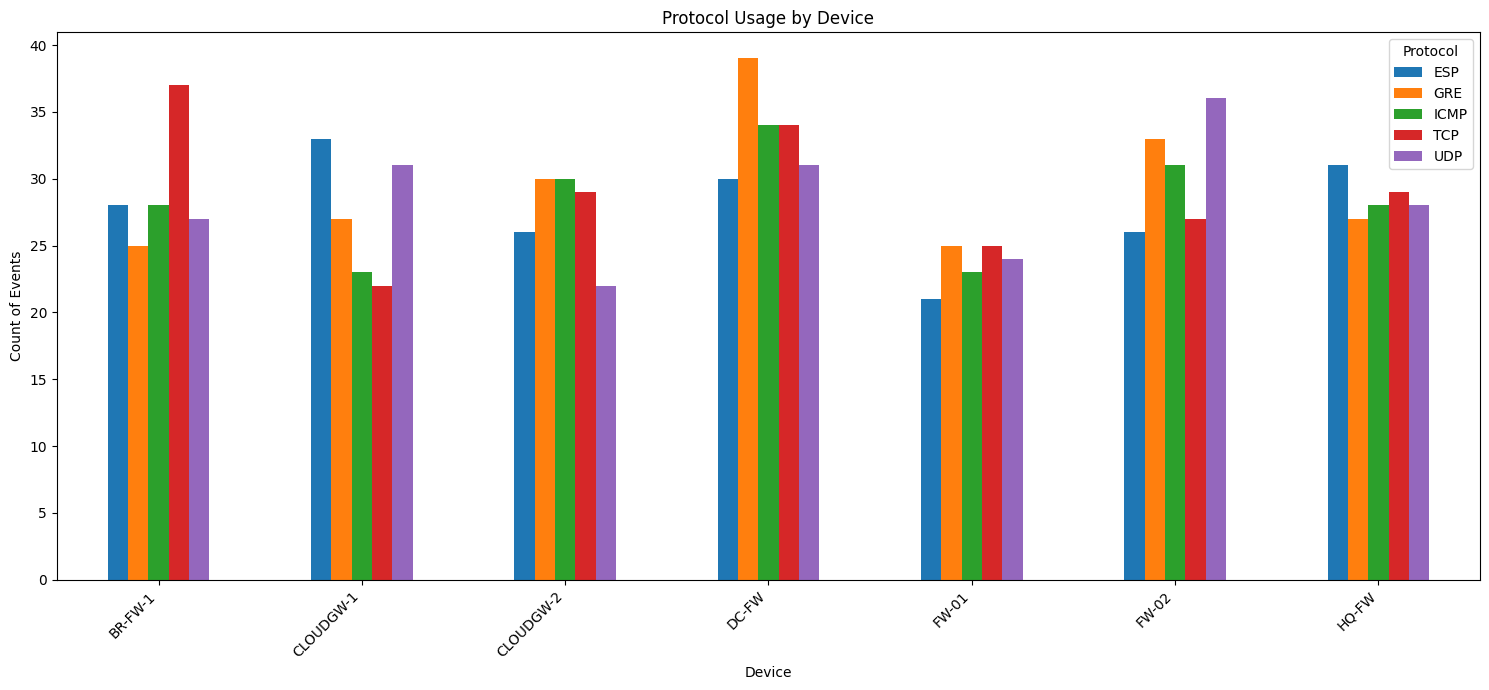

In [ ]:
import matplotlib.pyplot as plt

# Group by device and protocol, then count
device_protocol_counts = df.groupby(['device', 'protocol']).size().unstack(fill_value=0)

# Plotting the grouped bar chart
plt.figure(figsize=(15, 7))
device_protocol_counts.plot(kind='bar', stacked=False, figsize=(15, 7))

plt.title('Protocol Usage by Device')
plt.xlabel('Device')
plt.ylabel('Count of Events')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Protocol')
plt.tight_layout()
plt.show()